# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [12]:
corpus = '''
Ishq de fanniyar lad gaye
Meri jaan ke peechhe pad gaye
Seedhi laake dekho mere
Dil ki chhat pe chadh gaye
Sau sau awaazein maare akhiyan
Maare akhiyan, maare akhiyan
Usey neeche chhat se utaare akhiyan
Utaare akhiyan, utaare akhiyan
Sau sau awaazein maare akhiyan
Ikk uska naam pukaare
Sohne rang de Ranjheya
Tere hi jaise lagte hain sa
'''
print(corpus)


Ishq de fanniyar lad gaye
Meri jaan ke peechhe pad gaye
Seedhi laake dekho mere
Dil ki chhat pe chadh gaye
Sau sau awaazein maare akhiyan
Maare akhiyan, maare akhiyan
Usey neeche chhat se utaare akhiyan
Utaare akhiyan, utaare akhiyan
Sau sau awaazein maare akhiyan
Ikk uska naam pukaare
Sohne rang de Ranjheya
Tere hi jaise lagte hain sa



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [13]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 41
X shape: (47, 5)
y shape: (47,)


In [14]:
tokenizer.word_index


{'akhiyan': 1,
 'sau': 2,
 'maare': 3,
 'gaye': 4,
 'utaare': 5,
 'de': 6,
 'chhat': 7,
 'awaazein': 8,
 'ishq': 9,
 'fanniyar': 10,
 'lad': 11,
 'meri': 12,
 'jaan': 13,
 'ke': 14,
 'peechhe': 15,
 'pad': 16,
 'seedhi': 17,
 'laake': 18,
 'dekho': 19,
 'mere': 20,
 'dil': 21,
 'ki': 22,
 'pe': 23,
 'chadh': 24,
 'usey': 25,
 'neeche': 26,
 'se': 27,
 'ikk': 28,
 'uska': 29,
 'naam': 30,
 'pukaare': 31,
 'sohne': 32,
 'rang': 33,
 'ranjheya': 34,
 'tere': 35,
 'hi': 36,
 'jaise': 37,
 'lagte': 38,
 'hain': 39,
 'sa': 40}

In [15]:
sequences = tokenizer.texts_to_sequences([corpus])
sequences

[[9,
  6,
  10,
  11,
  4,
  12,
  13,
  14,
  15,
  16,
  4,
  17,
  18,
  19,
  20,
  21,
  22,
  7,
  23,
  24,
  4,
  2,
  2,
  8,
  3,
  1,
  3,
  1,
  3,
  1,
  25,
  26,
  7,
  27,
  5,
  1,
  5,
  1,
  5,
  1,
  2,
  2,
  8,
  3,
  1,
  28,
  29,
  30,
  31,
  32,
  33,
  6,
  34,
  35,
  36,
  37,
  38,
  39,
  40]]

# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [19]:
rnn_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [21]:
lstm_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [22]:
gru_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

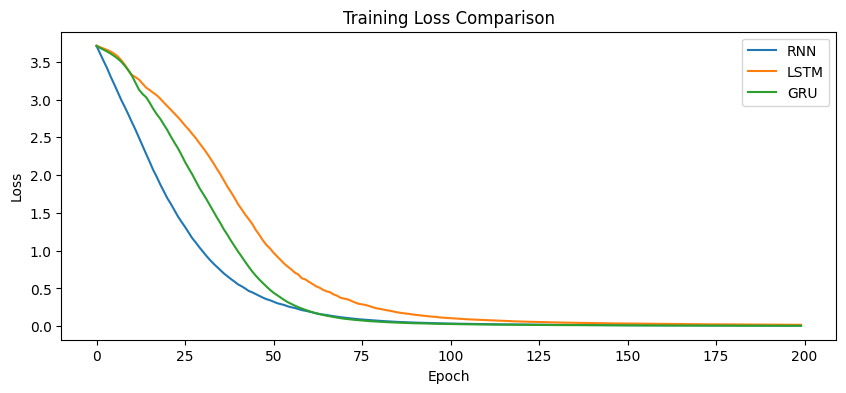

In [23]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [24]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [25]:
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning uska naam pukaare peechhe maare akhiyan maare akhiyan maare akhiyan
LSTM: deep learning sau sau awaazein maare akhiyan maare akhiyan akhiyan akhiyan akhiyan
GRU : deep learning neeche neeche chhat se utaare akhiyan utaare akhiyan gaye gaye


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**